# G4 Tool Overlap — Venn Diagrams

Venn diagrams comparing g4Discovery and rG4detector motif overlap for each threshold subset.

In [ ]:
import os
import math
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import sys; sys.path.insert(0, "/mnt/cbib/LNClassifier/paper/secondrna/workflow/")
from utils import g4_analysis_lib as lib

SAMPLE = "gencode.v47"
os.chdir("/mnt/cbib/LNClassifier/paper/secondrna")
print("Imports OK")

Imports OK


In [ ]:
intersect = lib.load_intersect(f"results/{SAMPLE}/{SAMPLE}.g4Discovery.rG4detector.intersect.bed")
peaks     = lib.load_peaks(f"results/{SAMPLE}/{SAMPLE}.rG4detector.peaks.bed")

union_df = lib.build_union_df(intersect, peaks)
print(f"union_df: {union_df.shape}  types: {union_df['type'].value_counts().to_dict()}")

union_df: (61850, 16)  types: {'RG4D only': 30570, 'G4D only': 16773, 'both': 14507}


/mnt/cbib/LNClassifier/paper/secondrna/workflow/utils/g4_analysis_lib.py:122: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  union["overlaps"] = union["overlaps"].fillna(False).astype(bool)


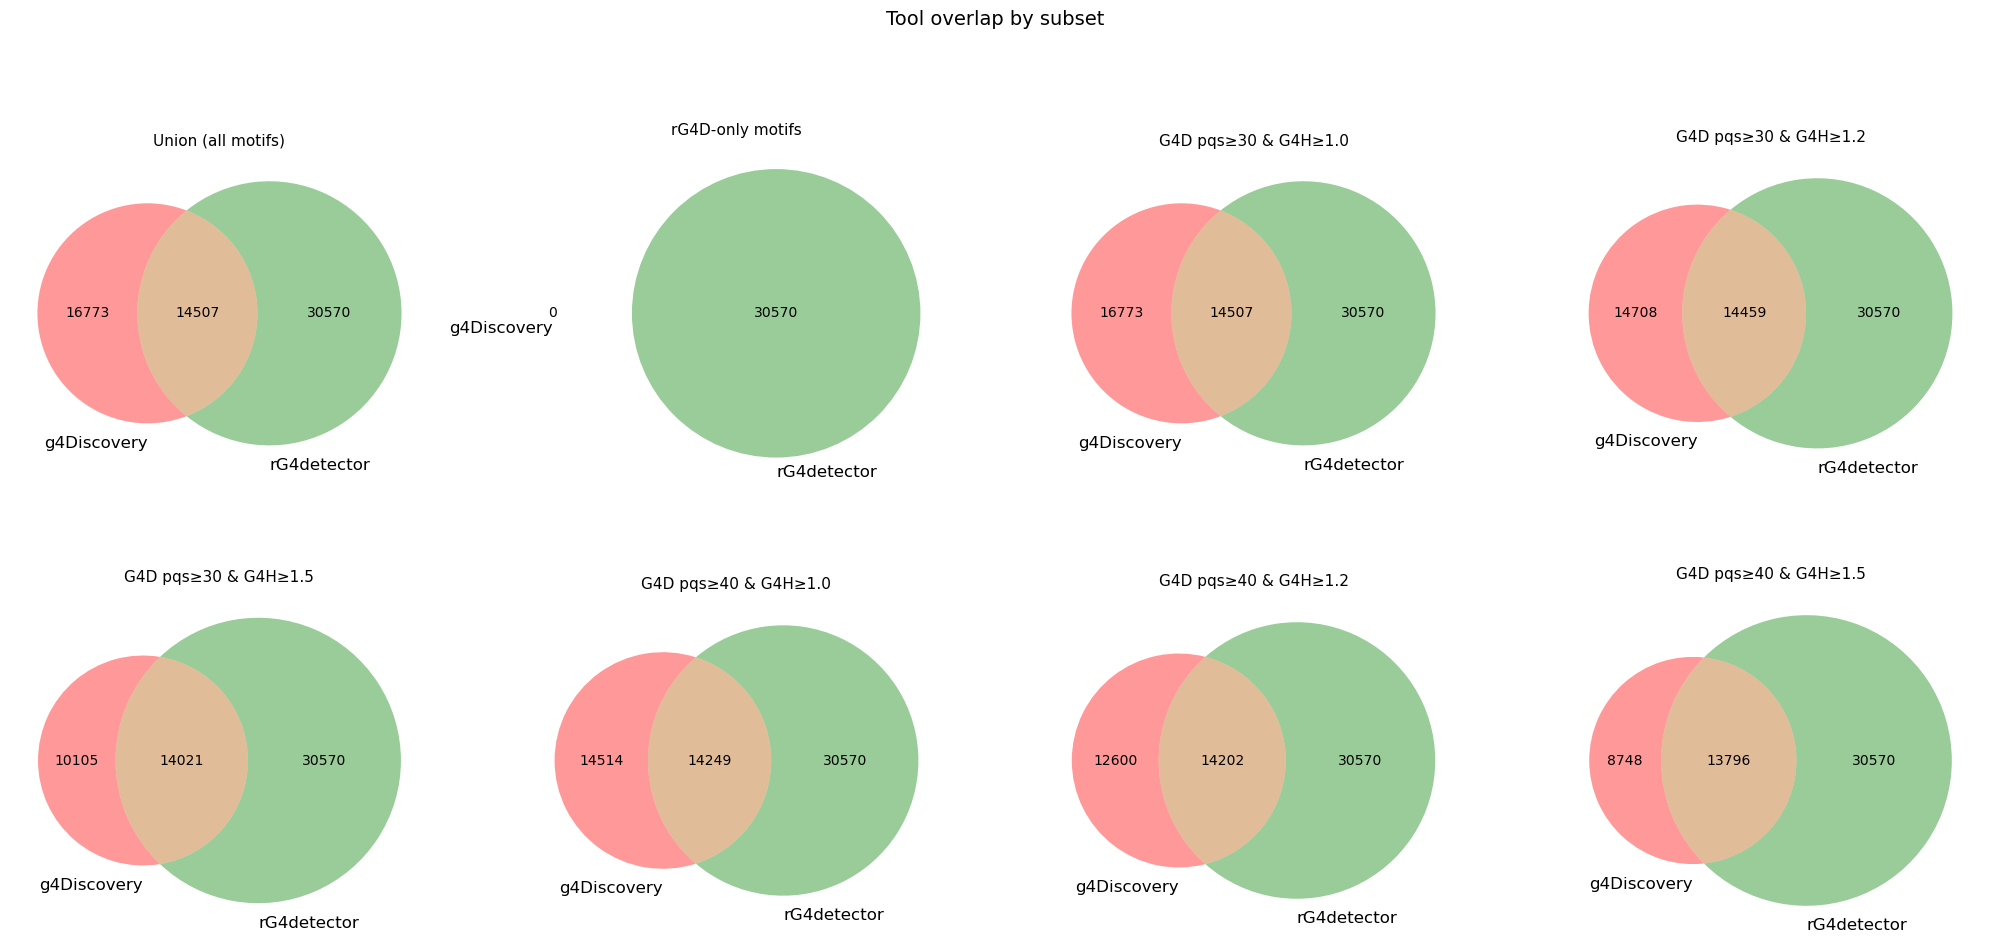

In [ ]:
subsets = lib.build_subsets(union_df)

ncols = 4
nrows = math.ceil(len(subsets) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = axes.flatten()

for ax, (spec, sdf) in zip(axes, subsets):
    agg = lib.compute_aggregate_stats(sdf)
    if agg["g4d_total"] > 0 or agg["rg4d_total"] > 0:
        venn2(
            subsets=(agg["g4d_only"], agg["rg4d_only"], agg["both"]),
            set_labels=("g4Discovery", "rG4detector"),
            ax=ax,
        )
    ax.set_title(spec.label, fontsize=11)

for ax in axes[len(subsets):]:
    ax.set_visible(False)

fig.suptitle("Tool overlap by subset", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Summarize overlap as % of total rG4detector points (first table only) + delta overlap column
# + include G4D total per row and G4D percentage wrt max G4D total

union_agg = next(lib.compute_aggregate_stats(sdf_) for spec_, sdf_ in subsets if spec_.name == "union")
rg4d_total_baseline = union_agg["rg4d_total"]

rows = []
for spec_, sdf_ in subsets:
    if spec_.name.startswith("pqs"):
        a = lib.compute_aggregate_stats(sdf_)
        pqs = int(spec_.name.split("_")[0].replace("pqs", ""))
        g4h = float(spec_.name.split("_")[1].replace("g4h", ""))
        rows.append({
            "subset": spec_.label,
            "spec_name": spec_.name,
            "pqs": pqs,
            "g4h": g4h,
            "both": a["both"],
            "overlap_vs_rg4d_total_%": 100 * a["both"] / rg4d_total_baseline if rg4d_total_baseline else 0.0,
            "g4d_total": a["g4d_total"],
        })

rows = sorted(rows, key=lambda x: (x["pqs"], x["g4h"]))

# New: % of G4D points wrt maximum G4D point number across subsets
max_g4d_total = max(r["g4d_total"] for r in rows) if rows else 0
for r in rows:
    r["g4d_pct_of_max_%"] = 100 * r["g4d_total"] / max_g4d_total if max_g4d_total else 0.0

prev_overlap = None
for r in rows:
    cur_overlap = r["overlap_vs_rg4d_total_%"]
    r["delta_overlap_pp"] = (cur_overlap - prev_overlap) if prev_overlap is not None else 0.0
    prev_overlap = cur_overlap

print(f"rG4detector baseline total (union): {rg4d_total_baseline}")
print(f"Max G4D total across subsets: {max_g4d_total}\n")
print(
    f"{'Subset':35s} {'Both':>8s} "
    f"{'Overlap vs rG4D total %':>25s} {'Δ overlap (pp)':>15s} {'G4D total':>10s} {'G4D % of max':>14s}"
)
print("-" * 125)

for r in rows:
    print(
        f"{r['subset'][:35]:35s} "
        f"{r['both']:8d} "
        f"{r['overlap_vs_rg4d_total_%']:24.2f}% "
        f"{r['delta_overlap_pp']:14.2f} "
        f"{r['g4d_total']:10d} "
        f"{r['g4d_pct_of_max_%']:13.2f}%"
    )


rG4detector baseline total (union): 45077
Max G4D total across subsets: 31280

Subset                                  Both   Overlap vs rG4D total %  Δ overlap (pp)  G4D total   G4D % of max
-----------------------------------------------------------------------------------------------------------------------------
G4D pqs≥30 & G4H≥1.0                   14507                    32.18%           0.00      31280        100.00%
G4D pqs≥30 & G4H≥1.2                   14459                    32.08%          -0.11      29167         93.24%
G4D pqs≥30 & G4H≥1.5                   14021                    31.10%          -0.97      24126         77.13%
G4D pqs≥40 & G4H≥1.0                   14249                    31.61%           0.51      28763         91.95%
G4D pqs≥40 & G4H≥1.2                   14202                    31.51%          -0.10      26802         85.68%
G4D pqs≥40 & G4H≥1.5                   13796                    30.61%          -0.90      22544         72.07%
